### 1-Librerias y reproducibilidad

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Reproducibility (best-effort)
import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

In [ ]:

# -----------------------------------------
# Data acquisition with offline fallback
# -----------------------------------------
DATA_CSV_CANDIDATES = [
    Path("data/BTC-USD.csv"),
    Path("../data/BTC-USD.csv"),
    Path("../../data/BTC-USD.csv"),
    Path("BTC-USD.csv"),
]

def try_load_cached_csv() -> pd.DataFrame | None:
    for p in DATA_CSV_CANDIDATES:
        if p.exists():
            df = pd.read_csv(p, parse_dates=["Date"])
            df = df.set_index("Date").sort_index()
            print(f"✅ Loaded cached BTC data from: {p.resolve()}")
            return df
    return None

df_btc = None

try:
    import yfinance as yf  # pip install yfinance

    df_btc = yf.download("BTC-USD", start="2015-01-01", interval="1d", auto_adjust=False, progress=False)
    if df_btc is None or len(df_btc) == 0:
        raise RuntimeError("Empty download from yfinance.")
    df_btc = df_btc.reset_index().set_index("Date").sort_index()
    print(f"✅ Downloaded BTC-USD from Yahoo Finance. Rows: {len(df_btc)}")

    # Save cache (best-effort) if running in a writable environment
    out_cache = Path("data/BTC-USD.csv")
    try:
        out_cache.parent.mkdir(parents=True, exist_ok=True)
        df_btc.reset_index().to_csv(out_cache, index=False)
        print(f"💾 Cached data saved to: {out_cache.resolve()}")
    except Exception as e:
        print(f"⚠️ Could not write cache file (ok in read-only builds): {e}")

except Exception as e:
    print(f"⚠️ yfinance download failed: {e}")
    df_btc = try_load_cached_csv()

if df_btc is None:
    raise FileNotFoundError(
        "Could not obtain BTC data. "
        "Install yfinance and ensure internet access, OR place a cached file at data/BTC-USD.csv."
    )

# We will use the Close price
if "Close" not in df_btc.columns:
    raise ValueError(f"Expected 'Close' column. Found: {list(df_btc.columns)}")

close = df_btc[["Close"]].dropna().astype(float)
print("Date range:", close.index.min().date(), "→", close.index.max().date())
display(close.head())

✅ Downloaded BTC-USD from Yahoo Finance. Rows: 4113
💾 Cached data saved to: C:\Users\inter\OneDrive - Universidad Externado de Colombia\Tercer Semestre\Topicos de mineria de datos\Talleres\RMR\Codigos\data\BTC-USD.csv
Date range: 2015-01-01 → 2026-04-06


Price,Close
Ticker,BTC-USD
Date,
2015-01-01,314.248993
2015-01-02,315.032013
2015-01-03,281.082001
2015-01-04,264.195007
2015-01-05,274.473999


#### Tendencia diaría de la serie del BTC-USD

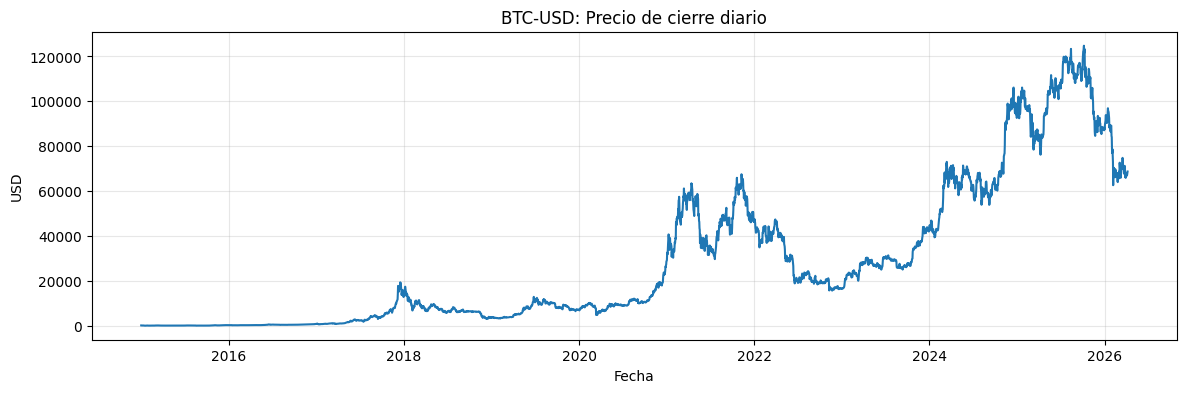

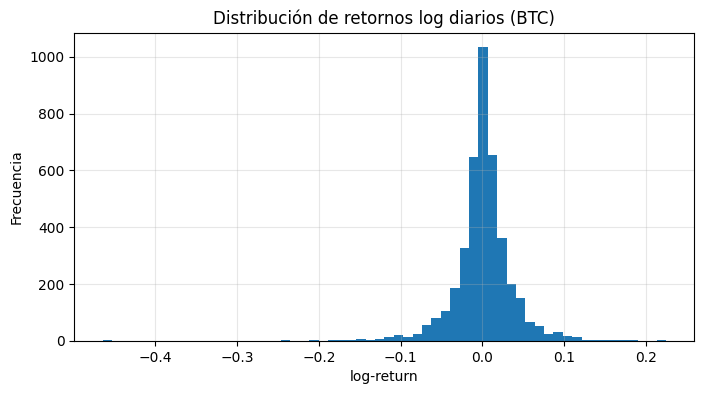

In [4]:

plt.figure(figsize=(14, 4))
plt.plot(close.index, close["Close"].values)
plt.title("BTC-USD: Precio de cierre diario")
plt.xlabel("Fecha")
plt.ylabel("USD")
plt.grid(True, alpha=0.3)
plt.show()

# Volatility hint: daily log-returns distribution
log_returns = np.log(close["Close"]).diff().dropna()
plt.figure(figsize=(8, 4))
plt.hist(log_returns.values, bins=60)
plt.title("Distribución de retornos log diarios (BTC)")
plt.xlabel("log-return")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.3)
plt.show()
